# Quantum Fourier Transform (QFT)

Author: Vanessa Knight

## Objective

This notebook introduces the **Quantum Fourier Transform (QFT)**, one of the most important algorithms in quantum computing.

Unlike the classical Fourier Transform, which analyzes frequencies in classical signals, the QFT transforms **probability amplitudes and phases** of quantum states.

The QFT is a core component of several quantum algorithms, including:

- Quantum Phase Estimation (QPE)
- Shor's Factoring Algorithm
- Quantum Simulation
- Period Finding

## Topics Covered

- Classical Fourier Transform vs QFT
- Phase
- Controlled Phase Gates
- Building the QFT
- SWAP Gates
- Circuit Analysis
- Applications

## Learning Goals

By the end of this notebook, I should be able to:

- Explain what the Quantum Fourier Transform does.
- Build a QFT circuit in Qiskit.
- Explain the role of phase.
- Understand why SWAP gates are required.
- Describe how QFT is used inside larger algorithms.

> The QFT does **not** search for answers like Grover's Algorithm. Instead, it transforms quantum phases into measurable information.

# 1. What Does the QFT Do?

The Quantum Fourier Transform changes the representation of a quantum state.

Instead of emphasizing computational basis states such as

$$
|00\rangle,\;
|01\rangle,\;
|10\rangle,\;
|11\rangle
$$

it transforms the **relative phases** of the amplitudes into a new basis.

This allows information that is hidden in quantum phases to become accessible through later measurements.

Unlike Grover's Algorithm, which amplifies probabilities,

the QFT reorganizes the quantum state according to its phase information.

## Why Is Phase Important?

One of the biggest lessons in quantum computing is:

**Measurement cannot directly observe phase.**

However...

Phase affects **interference**.

Interference changes **probabilities**.

Probabilities determine **measurement outcomes**.

This chain of events is why phase plays such an important role in quantum algorithms.

The Quantum Fourier Transform is one of the primary tools used to convert phase information into something we can eventually measure.

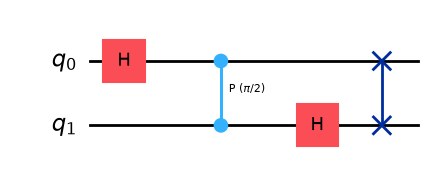

In [9]:
from math import pi
from qiskit import QuantumCircuit

# Two-qubit Quantum Fourier Transform
qc = QuantumCircuit(2)

# Step 1
qc.h(0)

# Step 2
qc.cp(pi/2, 1, 0)

# Step 3
qc.h(1)

# Step 4
qc.swap(0, 1)

qc.draw("mpl")

# 2. Building the Quantum Fourier Transform

The Quantum Fourier Transform is built from four operations.

## Step 1 — Hadamard Gate

```python
qc.h(0)
```

The Hadamard gate places the first qubit into superposition.

This prepares the qubit for the phase relationships that will be introduced next.

Unlike Grover's Algorithm, the Hadamard here is **not** preparing a search space.

Instead, it prepares the qubit for a change of basis.

## Step 2 — Controlled Phase Gate

```python
qc.cp(pi/2, 1, 0)
```

The controlled phase gate rotates the **phase** of qubit 0 by

$$
\frac{\pi}{2}
$$

only if qubit 1 is in the state

$$
|1\rangle.
$$

Unlike a CNOT gate, the controlled phase gate does **not** flip a qubit.

Instead, it changes the relative phase of the quantum state.

## Step 3 — Hadamard Gate

```python
qc.h(1)
```

The second Hadamard gate repeats the same idea for the second qubit.

After the controlled phase operation, this Hadamard helps transform the accumulated phase information into the Fourier basis.

At this point, the quantum state has been transformed into its Quantum Fourier representation.

## Step 4 — SWAP Gate

```python
qc.swap(0,1)
```

The final SWAP gate exchanges the positions of the two qubits.

Why?

The Quantum Fourier Transform naturally reverses the order of its output qubits.

The SWAP gate restores the qubits to the expected order.

Without the SWAP gate, the algorithm would still perform the Quantum Fourier Transform correctly, but the output qubits would appear in reverse order.

For larger QFT circuits, several SWAP gates may be required.

### Notes

One of the most common questions is:

> Why doesn't the controlled phase gate change the measurement?

The answer is:

The controlled phase gate only changes the **relative phase** between quantum states.

Phase cannot be observed directly.

Instead,

Phase

↓

Interference

↓

Probability

↓

Measurement

This is why the QFT is so powerful—it transforms hidden phase information into information that later quantum operations can reveal through measurement.

In [10]:
from qiskit import transpile
from qiskit_aer import AerSimulator

backend = AerSimulator()

optimized = transpile(qc, backend, optimization_level=3)

print("Qubits :", optimized.num_qubits)
print("Depth  :", optimized.depth())
print("Size   :", optimized.size())
print("Operations:")
print(optimized.count_ops())

Qubits : 2
Depth  : 3
Size   : 3
Operations:
OrderedDict({'h': 2, 'cp': 1})


# 3. Resource Analysis

Just like every other quantum algorithm, the Quantum Fourier Transform can be analyzed using several engineering metrics.

The most common are:

- **Number of Qubits** — How many qubits are required.
- **Circuit Depth** — The number of sequential gate layers.
- **Circuit Size** — The total number of quantum operations.
- **Gate Counts** — The number of each type of gate.

These metrics become increasingly important on real quantum hardware, where deeper circuits accumulate more noise.

## Why Does QFT Use Controlled Phase Gates?

Earlier, we learned that:

- Hadamard gates create superposition.
- Controlled gates create relationships between qubits.

The controlled phase gate serves a different purpose.

Instead of flipping a qubit, it stores information in the **relative phase** of the quantum state.

The Quantum Fourier Transform uses many controlled phase gates because it is designed to manipulate phase information rather than measurement probabilities directly.

Later algorithms, such as Quantum Phase Estimation and Shor's Algorithm, use this encoded phase information to solve difficult computational problems.

## Why Does the QFT Scale So Well?

For two qubits, the Quantum Fourier Transform is very small.

As more qubits are added, the circuit grows by adding additional:

- Hadamard gates
- Controlled phase gates
- SWAP gates

Although the circuit becomes larger, the overall structure remains remarkably regular.

This makes the QFT an excellent building block for larger quantum algorithms.

Many advanced quantum algorithms simply place the QFT inside a larger circuit.

### Notes

One of the biggest insights while learning the Quantum Fourier Transform was realizing that it is **not** a search algorithm.

Unlike Grover's Algorithm, which increases the probability of the correct answer,

the QFT reorganizes the quantum state's **phase information**.

Later algorithms use this transformed phase information to solve problems such as:

- Period finding
- Phase estimation
- Integer factorization

The QFT is therefore best thought of as a **tool** rather than a complete algorithm by itself.

# Notebook Summary

Congratulations! You have completed the Quantum Fourier Transform notebook.

## Concepts Learned

✅ Quantum Fourier Transform (QFT)

✅ Phase

✅ Controlled Phase Gates

✅ Hadamard Gates

✅ SWAP Gates

✅ Phase Information

✅ Resource Analysis

## Key Ideas

- The Quantum Fourier Transform changes the basis of a quantum state.
- Unlike Grover's Algorithm, the QFT does **not** search for a solution.
- Controlled phase gates encode information into the relative phases of quantum states.
- The QFT transforms phase information into a form that later algorithms can use.
- The output qubits naturally appear in reverse order, requiring SWAP gates.

## Looking Ahead

The next notebook introduces **Variational Quantum Algorithms (VQE)**.

Instead of using a fixed algorithm, VQE builds a parameterized quantum circuit whose parameters are optimized by a classical computer.

This hybrid quantum-classical approach is one of the most important areas of modern quantum computing.

# 🎯 Interview Corner

### What is the Quantum Fourier Transform?

The Quantum Fourier Transform (QFT) is a quantum algorithm that transforms the phase information of a quantum state into a new basis, making it useful for algorithms such as Quantum Phase Estimation and Shor's Algorithm.

### Does the QFT search for an answer?

No.

Unlike Grover's Algorithm, the QFT reorganizes phase information rather than amplifying the probability of a marked state.

### Why are controlled phase gates used?

Controlled phase gates modify the **relative phase** between quantum states without directly changing measurement probabilities.

### Why are SWAP gates used?

The QFT naturally reverses the order of its output qubits.

SWAP gates restore the expected qubit ordering.

# Quick Self-Review

Try answering these questions without looking back.

1. What does the Quantum Fourier Transform do?

2. What is the purpose of a controlled phase gate?

3. Does the controlled phase gate directly change measurement probabilities?

4. Why is the Hadamard gate used in the QFT?

5. Why are SWAP gates needed?

6. What is the relationship between phase and interference?

7. Which major algorithms use the QFT?

8. Is the QFT a complete algorithm by itself?

9. What engineering metrics can be used to analyze a QFT circuit?

10. How does the QFT differ from Grover's Algorithm?

# Key Takeaways

- The Quantum Fourier Transform is one of the most important building blocks in quantum computing.
- It manipulates **phase information**, not search probabilities.
- Controlled phase gates encode phase relationships between qubits.
- SWAP gates restore the natural qubit ordering after the transformation.
- The QFT is used inside larger algorithms such as Quantum Phase Estimation and Shor's Algorithm.

Understanding the QFT is a major milestone because it connects foundational quantum gates with advanced quantum algorithms.